# Subplots in Matplotlib
---
- Subplots allow you to show multiple plots in a single figure, side-by-side or in a grid layout. This is helpful when comparing different datasets or aspects of the same data.

## Basic Subplot (1 row, 2 columns)

In [1]:
import matplotlib.pyplot as plt
from math import sqrt

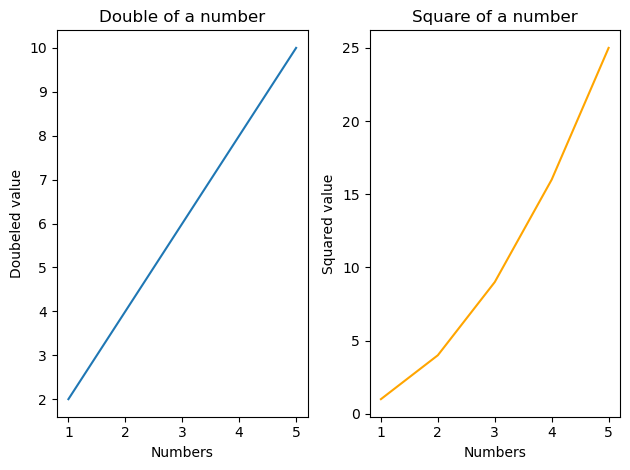

In [2]:
x = [1, 2, 3, 4, 5]
y1 = [i * 2 for i in x]
y2 = [i ** 2 for i in x]

plt.subplot(1,2,1)
plt.plot(x,y1)
plt.title("Double of a number")
plt.xlabel("Numbers")
plt.ylabel("Doubeled value")
plt.subplot(1,2,2)
plt.title("Square of a number")
plt.xlabel("Numbers")
plt.ylabel("Squared value")
plt.plot(x,y2 , color = 'orange')
plt.tight_layout()

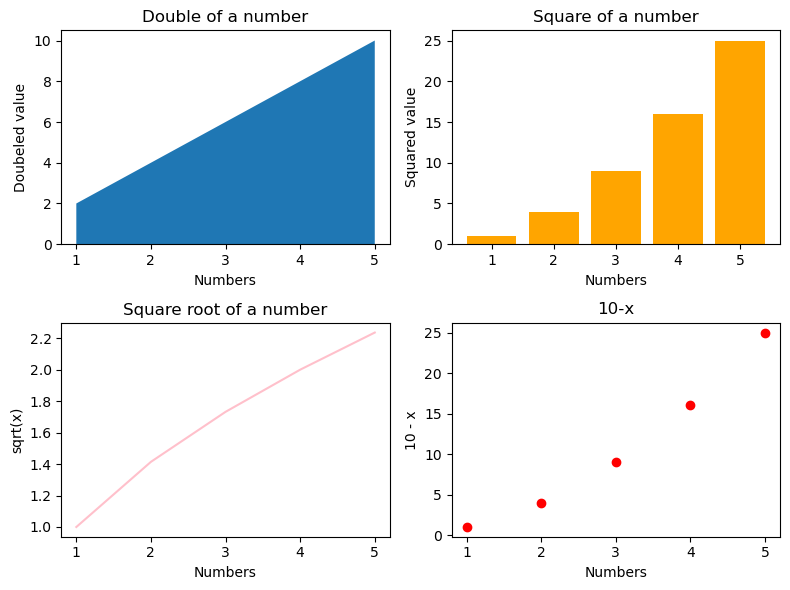

In [3]:
y3 = [sqrt(i) for i in x]
y4 = [10 - i for i in x]
plt.figure(figsize=(8,6))
plt.subplot(2,2,1)
plt.stackplot(x,y1)
plt.title("Double of a number")
plt.xlabel("Numbers")
plt.ylabel("Doubeled value")
plt.subplot(2,2,2)
plt.title("Square of a number")
plt.xlabel("Numbers")
plt.ylabel("Squared value")
plt.bar(x,y2 , color = 'orange')
plt.subplot(2,2,3)
plt.plot(x,y3 , color='pink')
plt.title("Square root of a number")
plt.xlabel("Numbers")
plt.ylabel("sqrt(x)")
plt.subplot(2,2,4)
plt.title("10-x")
plt.xlabel("Numbers")
plt.ylabel("10 - x")
plt.scatter(x,y2 , color = 'red')
plt.tight_layout()


## Using plt.subplots() for Clean Code

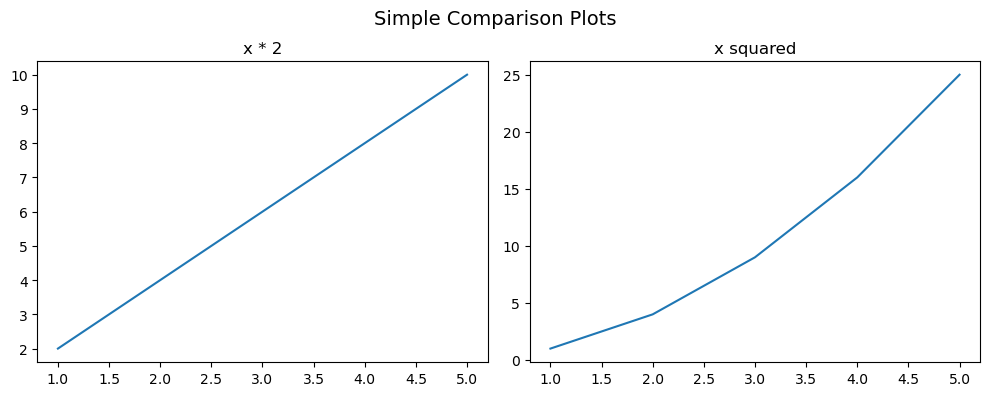

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(x, y1)
axs[0].set_title('x * 2')
axs[1].plot(x, y2)
axs[1].set_title('x squared')
fig.suptitle('Simple Comparison Plots', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85) # So title doesn't overlap
# fig.savefig('my_plots.png')

## Looping over Subplots

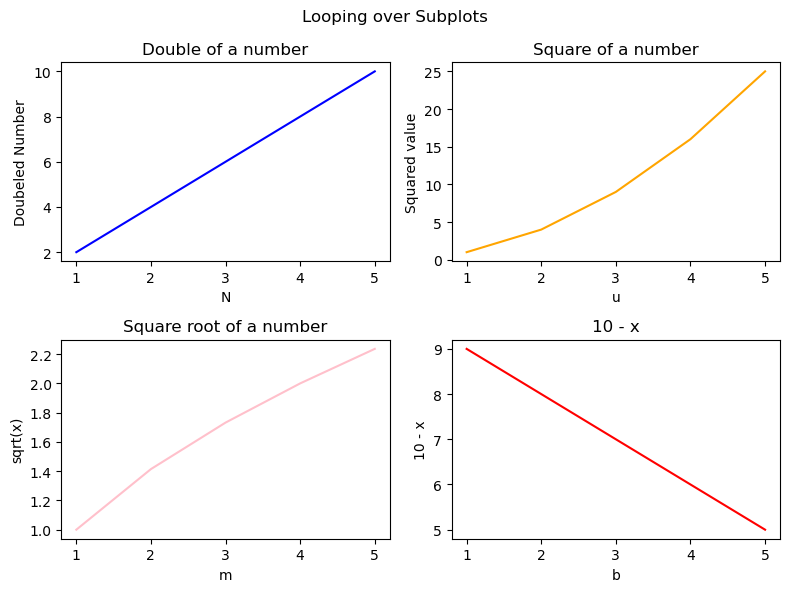

In [18]:
fig,axs = plt.subplots(2,2 ,figsize = (8,6))
ys = [y1,y2,y3,y4]
titles = ['Double of a number','Square of a number', 'Square root of a number','10 - x']
colors = ['blue', 'orange' , 'pink' , 'red']
ylb = ['Doubeled Number','Squared value','sqrt(x)','10 - x']
xlb = 'Numbers'

for i in range(2):
    for j in range(2):
        idx = i * 2 + j
        axs[i,j].plot(x,ys[idx] , color=colors[idx])
        axs[i,j].set_xlabel(xlb[idx])
        axs[i,j].set_ylabel(ylb[idx])
        axs[i,j].set_title(titles[idx])
        # axs[i,j].colors(colors[idx]) ---> can't do like this
plt.suptitle("Looping over Subplots")
plt.tight_layout()

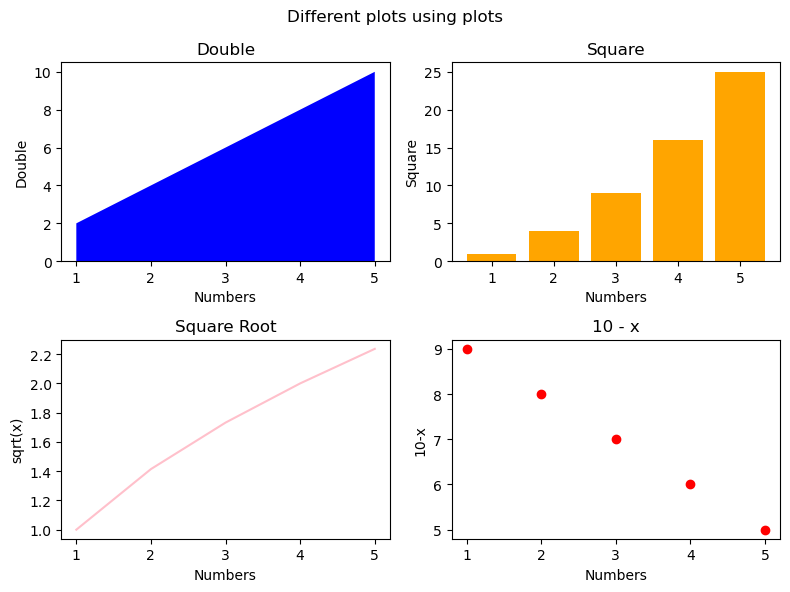

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

ys = [y1, y2, y3, y4]
titles = ['Double', 'Square', 'Square Root', '10 - x']
colors = ['blue', 'orange', 'pink', 'red']
ylb = ['Double', 'Square', 'sqrt(x)', '10-x']

plots = [
    lambda ax, x, y, c: ax.stackplot(x, y, colors=[c]),
    lambda ax, x, y, c: ax.bar(x, y, color=c),
    lambda ax, x, y, c: ax.plot(x, y, color=c),
    lambda ax, x, y, c: ax.scatter(x, y, color=c)
]

for i in range(2):
    for j in range(2):
        idx = i * 2 + j

        plots[idx](axs[i, j], x, ys[idx], colors[idx])

        axs[i, j].set_title(titles[idx])
        axs[i, j].set_xlabel("Numbers")
        axs[i, j].set_ylabel(ylb[idx])

plt.suptitle("Different plots using plots")
plt.tight_layout()